# Notebook 2 - The corrected study: every table and figure of the paper

All numbers shown here are read from the JSON files in `v2/results/` that the experiment scripts wrote, or recomputed live where that is cheap (privacy accounting, unit tests, a full re-run of one cross-validation split). Nothing is typed in by hand.

**Contents**

1. Provenance and file integrity
2. Unit tests of the DP-SGD code
3. Privacy accounting, with a Monte-Carlo check of the theorem
4. Non-private baselines on three datasets
5. Utility under DP-SGD, private baselines, paired tests
6. Sensitivity: Credit_History handling, MLP tuning, training loss
7. Learning curve on the 30,000-row data
8. Explanation stability
9. Membership-inference audit
10. Group-level diagnostics
11. One split re-run from scratch and compared with the saved result

In [1]:
import os, sys, json, subprocess, hashlib, platform, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 30); pd.set_option('display.max_colwidth', 70)
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
V2 = os.path.join(ROOT, 'v2'); sys.path.insert(0, V2); os.chdir(V2)
import analysis as A
from IPython.display import Image, display, Markdown
fig = lambda name, w=620: display(Image(os.path.join(V2, 'figures', name), width=w))
print('python', platform.python_version())

python 3.12.3


## 1. Provenance and file integrity

The manifest was written by `make_manifest.py` after the last experiment finished. Here every file is hashed again and compared with it.

In [2]:
M = json.load(open(os.path.join(V2, 'MANIFEST.json')))
print('manifest created (UTC):', M['created_utc']); print('git commit            :', M['git_commit'][:12]); print('library versions      :', M['versions'])
bad = []
for rel, h in M['sha256'].items():
    p = os.path.join(ROOT, rel)
    if not os.path.exists(p) or hashlib.sha256(open(p, 'rb').read()).hexdigest() != h: bad.append(rel)
print(f'{len(M["sha256"])} files checked, {len(bad)} differ from the manifest', bad[:5])
assert not bad, 'files changed after the manifest was written'

manifest created (UTC): 2026-10-03T05:43:29+00:00
git commit            : 8a95b30464a8
library versions      : {'numpy': '2.4.4', 'scipy': '1.17.1', 'scikit-learn': '1.8.0', 'pandas': '3.0.2', 'catboost': '1.2.10', 'xgboost': '3.4.1', 'interpret': '0.7.8', 'dp-accounting': '0.6.0'}
75 files checked, 0 differ from the manifest []


In [3]:
from pipeline import load
rows = []
for d in A.DS:
    ds = load(d); p = ds.make_prep().fit(ds.df); rows.append({'dataset': d, 'rows': len(ds.df), 'raw fields': ds.df.shape[1], 'model inputs': len(p.cols), 'adverse-class rate': round(float(ds.y.mean()), 4), 'missing cells': int(ds.df.isna().sum().sum())})
pd.DataFrame(rows)

,dataset,rows,raw fields,model inputs,adverse-class rate,missing cells
0,loan,614,11,17,0.3127,149
1,german,1000,20,61,0.3000,0
2,taiwan,30000,23,29,0.2212,0


## 2. Unit tests of the DP-SGD implementation

Per-example gradients against the original loop code, a numerical gradient check, the clipping bound, the injected-noise standard deviation, the Poisson sampling rate and a hand-computed one-step update.

In [4]:
r = subprocess.run([sys.executable, 'tests.py'], capture_output=True, text=True, cwd=V2); print(r.stdout[-1400:]); assert r.returncode == 0 and 'ALL TESTS PASSED' in r.stdout

1. max |grad_vec - grad_loop| = 1.3322676295501878e-15
2. max |numerical - analytic| gradient = 1.5223806243414018e-10
3. max clipped norm = 1.0000000000000002 (C = 1.0 )
4. empirical noise std = 9.988, expected sigma*C = 10.000
5. sampling rate 0.203
6. one-step update on a 2-row batch matches lr * mean gradient
7. mean_grad == mean of per-example gradients
8. linear model gradient = x*(p-y)
ALL TESTS PASSED



## 3. Privacy accounting

For 30 full-batch steps the privacy loss is exactly Gaussian (Theorem 1 of the paper, proof in Appendix A). The table compares the advanced-composition formula with the exact accountant, our closed form against Google's PLD accountant, and the Rényi accountant. The live computation below does not read any saved file.

In [5]:
from accounting import eps_fullbatch_exact, eps_pld, eps_rdp, eps_advanced_paper
rows = []
for s in (200, 100, 60, 40, 25, 15):
    e_adv, d_act = eps_advanced_paper(s, 30, 1/491)
    rows.append({'sigma': s, 'advanced comp. eps (nominal delta 1/491)': round(e_adv, 3), 'delta actually achieved': round(d_act, 4), 'exact eps, delta=1/491': round(eps_fullbatch_exact(s, 30, 1/491), 3),
                 'exact eps, delta=1e-5': round(eps_fullbatch_exact(s, 30, 1e-5), 3), 'PLD eps, delta=1e-5': round(eps_pld(s, 30, 1e-5), 3), 'RDP eps, delta=1e-5': round(eps_rdp(s, 30, 1e-5), 3)})
T = pd.DataFrame(rows); display(T)
assert np.allclose(T['exact eps, delta=1e-5'], T['PLD eps, delta=1e-5'], atol=2e-3); print('closed form == PLD to 3 decimals')
print('RDP exceeds the exact value by %.0f%% to %.0f%%' % (100*(T['RDP eps, delta=1e-5']/T['exact eps, delta=1e-5']-1).min(), 100*(T['RDP eps, delta=1e-5']/T['exact eps, delta=1e-5']-1).max()))

,sigma,advanced comp. eps (nominal delta 1/491),delta actually achieved,"exact eps, delta=1/491","exact eps, delta=1e-5","PLD eps, delta=1e-5","RDP eps, delta=1e-5"
0,200,0.394,0.0316,0.029,0.083,0.083,0.093
1,100,0.810,0.0316,0.077,0.177,0.177,0.197
2,60,1.400,0.0316,0.150,0.308,0.308,0.340
3,40,2.197,0.0316,0.251,0.480,0.480,0.527
4,25,3.804,0.0316,0.449,0.802,0.802,0.877
5,15,7.269,0.0316,0.838,1.406,1.406,1.532


closed form == PLD to 3 decimals
RDP exceeds the exact value by 9% to 12%


,sigma,k,eps,delta Monte Carlo,delta closed form
0,15,30,0.25,0.05967,0.06011
1,15,30,0.50,0.01807,0.01817
2,15,30,1.00,0.00053,0.00055
3,8,30,0.25,0.18269,0.18320
4,8,30,0.50,0.11524,0.11536
5,8,30,1.00,0.03469,0.03468
6,3,30,0.25,0.59318,0.59248
7,3,30,0.50,0.54528,0.54459
8,3,30,1.00,0.44709,0.44661


largest relative deviation (rows with delta > 1e-3): 0.007


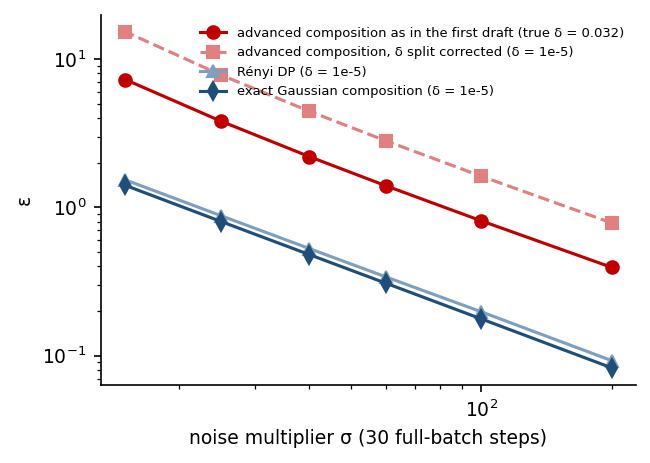

In [6]:
# Monte-Carlo check of equation (1), done from scratch here (150,000 samples per row)
from scipy.stats import norm
rng = np.random.default_rng(1); rows = []
for s, k in ((15, 30), (8, 30), (3, 30)):
    x = rng.normal(0, s, size=(150000, k)); L = (k - 2*x.sum(1))/(2*s*s)
    for eps in (0.25, 0.5, 1.0):
        mu = np.sqrt(k)/s; cf = norm.cdf(-eps/mu + mu/2) - np.exp(eps)*norm.cdf(-eps/mu - mu/2)
        rows.append({'sigma': s, 'k': k, 'eps': eps, 'delta Monte Carlo': round(float(np.mean(np.maximum(0, 1-np.exp(eps-L)))), 5), 'delta closed form': round(float(cf), 5)})
mc = pd.DataFrame(rows); display(mc); print('largest relative deviation (rows with delta > 1e-3): %.3f' % (abs(mc['delta Monte Carlo']/mc['delta closed form']-1)[mc['delta closed form'] > 1e-3]).max())
fig('fig_accountants.png', 420)

## 4. Non-private baselines

Mean ± 95% Nadeau-Bengio interval over the outer splits. Positive class = adverse outcome.

In [7]:
for d in A.DS:
    R = A.cv(d); print(f'--- {A.NAMES[d]}: {len(R)} outer splits'); display(A.nonprivate_table(d))

--- Loan approval (n=614): 25 outer splits


,Model,Accuracy,AUC,Bal. acc.,MCC,Recall (adverse)
0,Majority class,0.687 ± 0.004,0.500 ± 0.000,0.500 ± 0.000,0.000 ± 0.000,0.000 ± 0.000
1,Single-feature rule,0.809 ± 0.021,0.705 ± 0.034,0.705 ± 0.034,0.541 ± 0.060,0.427 ± 0.071
2,Logistic regression (L2),0.802 ± 0.026,0.752 ± 0.043,0.702 ± 0.038,0.515 ± 0.075,0.436 ± 0.075
3,Random forest,0.808 ± 0.037,0.779 ± 0.061,0.718 ± 0.045,0.533 ± 0.101,0.477 ± 0.079
4,CatBoost,0.805 ± 0.036,0.762 ± 0.057,0.723 ± 0.042,0.524 ± 0.094,0.505 ± 0.074
5,XGBoost,0.798 ± 0.031,0.766 ± 0.058,0.722 ± 0.039,0.504 ± 0.081,0.521 ± 0.078
6,"MLP (16-8), tuned",0.796 ± 0.024,0.729 ± 0.049,0.701 ± 0.036,0.499 ± 0.069,0.448 ± 0.085


--- German Credit (n=1000): 15 outer splits


,Model,Accuracy,AUC,Bal. acc.,MCC,Recall (adverse)
0,Majority class,0.700 ± 0.000,0.500 ± 0.000,0.500 ± 0.000,0.000 ± 0.000,0.000 ± 0.000
1,Logistic regression (L2),0.747 ± 0.030,0.777 ± 0.042,0.671 ± 0.030,0.369 ± 0.071,0.481 ± 0.063
2,Random forest,0.739 ± 0.022,0.792 ± 0.041,0.586 ± 0.031,0.286 ± 0.092,0.204 ± 0.060
3,CatBoost,0.775 ± 0.030,0.796 ± 0.034,0.692 ± 0.034,0.429 ± 0.077,0.486 ± 0.051
4,XGBoost,0.763 ± 0.034,0.791 ± 0.037,0.685 ± 0.040,0.404 ± 0.087,0.489 ± 0.068
5,"MLP (16-8), tuned",0.726 ± 0.022,0.735 ± 0.034,0.603 ± 0.047,0.262 ± 0.087,0.293 ± 0.125


--- Taiwan card default (n=30000): 10 outer splits


,Model,Accuracy,AUC,Bal. acc.,MCC,Recall (adverse)
0,Majority class,0.779 ± 0.000,0.500 ± 0.000,0.500 ± 0.000,0.000 ± 0.000,0.000 ± 0.000
1,Single-feature rule,0.780 ± 0.006,0.686 ± 0.010,0.686 ± 0.010,0.368 ± 0.019,0.517 ± 0.020
2,Logistic regression (L2),0.807 ± 0.004,0.747 ± 0.012,0.606 ± 0.006,0.323 ± 0.016,0.247 ± 0.010
3,Random forest,0.819 ± 0.006,0.777 ± 0.009,0.644 ± 0.012,0.387 ± 0.024,0.330 ± 0.024
4,CatBoost,0.821 ± 0.005,0.784 ± 0.010,0.660 ± 0.009,0.406 ± 0.020,0.370 ± 0.016
5,XGBoost,0.821 ± 0.005,0.784 ± 0.009,0.659 ± 0.009,0.406 ± 0.021,0.368 ± 0.016
6,"MLP (16-8), tuned",0.818 ± 0.008,0.770 ± 0.010,0.658 ± 0.021,0.397 ± 0.032,0.371 ± 0.054


## 5. Utility under DP-SGD

Test AUC by method and ε (δ = 1e-5). The noise multiplier is solved per fold from the target ε.

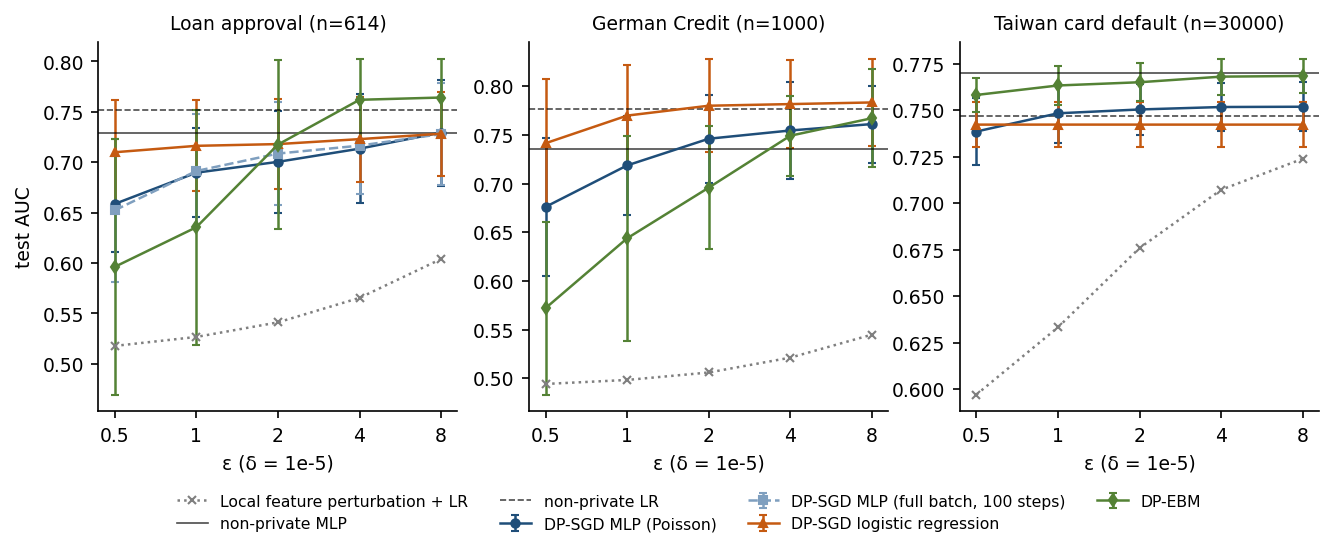

--- Loan approval (n=614) (AUC)


,Method,ε=0.5,ε=1,ε=2,ε=4,ε=8
0,DP-SGD MLP (Poisson),0.659 ± 0.047,0.690 ± 0.044,0.700 ± 0.050,0.713 ± 0.054,0.729 ± 0.053
1,"DP-SGD MLP (full batch, 100 steps)",0.652 ± 0.071,0.691 ± 0.057,0.708 ± 0.051,0.716 ± 0.048,0.728 ± 0.051
2,DP-SGD logistic regression,0.710 ± 0.052,0.716 ± 0.045,0.718 ± 0.045,0.723 ± 0.042,0.728 ± 0.042
3,DP-EBM,0.596 ± 0.127,0.635 ± 0.116,0.717 ± 0.084,0.762 ± 0.041,0.764 ± 0.038
4,Local feature perturbation + LR,0.518 ± 0.109,0.527 ± 0.108,0.541 ± 0.106,0.565 ± 0.102,0.604 ± 0.094


--- German Credit (n=1000) (AUC)


,Method,ε=0.5,ε=1,ε=2,ε=4,ε=8
0,DP-SGD MLP (Poisson),0.676 ± 0.071,0.719 ± 0.051,0.746 ± 0.045,0.754 ± 0.050,0.761 ± 0.040
1,DP-SGD logistic regression,0.741 ± 0.066,0.770 ± 0.052,0.780 ± 0.048,0.782 ± 0.045,0.783 ± 0.045
2,DP-EBM,0.572 ± 0.089,0.644 ± 0.105,0.696 ± 0.063,0.749 ± 0.041,0.767 ± 0.050
3,Local feature perturbation + LR,0.494 ± 0.084,0.498 ± 0.084,0.506 ± 0.084,0.521 ± 0.084,0.545 ± 0.082


--- Taiwan card default (n=30000) (AUC)


,Method,ε=0.5,ε=1,ε=2,ε=4,ε=8
0,DP-SGD MLP (Poisson),0.738 ± 0.018,0.748 ± 0.016,0.750 ± 0.014,0.752 ± 0.013,0.752 ± 0.013
1,DP-SGD logistic regression,0.742 ± 0.012,0.742 ± 0.012,0.742 ± 0.012,0.742 ± 0.012,0.742 ± 0.012
2,DP-EBM,0.758 ± 0.009,0.763 ± 0.011,0.765 ± 0.010,0.768 ± 0.010,0.768 ± 0.009
3,Local feature perturbation + LR,0.597 ± 0.098,0.633 ± 0.073,0.676 ± 0.041,0.707 ± 0.027,0.724 ± 0.020


In [8]:
fig('fig_privacy_utility.png', 760)
for d in A.DS: print('---', A.NAMES[d], '(AUC)'); display(A.dp_table(d, 'auc'))

In [9]:
for d in A.DS: print('---', A.NAMES[d], '(accuracy)'); display(A.dp_table(d, 'acc'))

--- Loan approval (n=614) (accuracy)


,Method,ε=0.5,ε=1,ε=2,ε=4,ε=8
0,DP-SGD MLP (Poisson),0.727 ± 0.052,0.766 ± 0.052,0.787 ± 0.039,0.796 ± 0.038,0.805 ± 0.023
1,"DP-SGD MLP (full batch, 100 steps)",0.710 ± 0.038,0.754 ± 0.055,0.775 ± 0.058,0.788 ± 0.046,0.803 ± 0.027
2,DP-SGD logistic regression,0.780 ± 0.052,0.791 ± 0.044,0.797 ± 0.039,0.799 ± 0.038,0.798 ± 0.038
3,DP-EBM,0.686 ± 0.078,0.724 ± 0.068,0.761 ± 0.058,0.799 ± 0.027,0.798 ± 0.028
4,Local feature perturbation + LR,0.687 ± 0.004,0.687 ± 0.004,0.687 ± 0.004,0.687 ± 0.004,0.687 ± 0.004


--- German Credit (n=1000) (accuracy)


,Method,ε=0.5,ε=1,ε=2,ε=4,ε=8
0,DP-SGD MLP (Poisson),0.700 ± 0.011,0.705 ± 0.022,0.716 ± 0.024,0.725 ± 0.034,0.740 ± 0.028
1,DP-SGD logistic regression,0.715 ± 0.036,0.736 ± 0.035,0.740 ± 0.033,0.741 ± 0.032,0.747 ± 0.032
2,DP-EBM,0.638 ± 0.084,0.682 ± 0.052,0.703 ± 0.018,0.734 ± 0.024,0.740 ± 0.025
3,Local feature perturbation + LR,0.700 ± 0.000,0.700 ± 0.000,0.700 ± 0.000,0.700 ± 0.000,0.700 ± 0.000


--- Taiwan card default (n=30000) (accuracy)


,Method,ε=0.5,ε=1,ε=2,ε=4,ε=8
0,DP-SGD MLP (Poisson),0.815 ± 0.008,0.819 ± 0.005,0.820 ± 0.005,0.819 ± 0.005,0.819 ± 0.005
1,DP-SGD logistic regression,0.794 ± 0.010,0.794 ± 0.009,0.795 ± 0.009,0.795 ± 0.009,0.795 ± 0.009
2,DP-EBM,0.791 ± 0.005,0.797 ± 0.005,0.801 ± 0.003,0.804 ± 0.004,0.805 ± 0.004
3,Local feature perturbation + LR,0.779 ± 0.000,0.779 ± 0.000,0.779 ± 0.000,0.779 ± 0.000,0.779 ± 0.000


### Paired comparisons (corrected resampled t-test, Holm-adjusted within each dataset)

In [10]:
for d in A.DS: print('---', A.NAMES[d]); display(A.paired_table(d))

--- Loan approval (n=614)


,Comparison,ΔAUC [95% CI],p (Holm),ΔAccuracy [95% CI],p (Holm)
0,Non-private MLP vs logistic regression,"-0.023 [-0.055, +0.008]",1.000,"-0.006 [-0.029, +0.017]",1.000
1,Non-private MLP vs single-feature rule,"+0.024 [-0.011, +0.058]",1.000,"-0.013 [-0.037, +0.011]",1.000
2,DP-SGD MLP (ε=1) vs non-private MLP,"-0.040 [-0.081, +0.001]",0.523,"-0.030 [-0.077, +0.018]",1.000
3,DP-SGD MLP (ε=4) vs non-private MLP,"-0.016 [-0.055, +0.023]",1.000,"-0.000 [-0.037, +0.037]",1.000
4,DP-SGD MLP (ε=8) vs non-private MLP,"+0.000 [-0.034, +0.035]",1.000,"+0.009 [-0.013, +0.031]",1.000
5,DP-SGD LR (ε=1) vs DP-SGD MLP (ε=1),"+0.027 [-0.022, +0.075]",1.000,"+0.024 [-0.036, +0.085]",1.000
6,DP-EBM (ε=1) vs DP-SGD LR (ε=1),"-0.081 [-0.203, +0.042]",1.000,"-0.067 [-0.146, +0.011]",0.899
7,DP-SGD LR (ε=4) vs DP-SGD MLP (ε=4),"+0.009 [-0.034, +0.053]",1.000,"+0.003 [-0.034, +0.040]",1.000
8,DP-EBM (ε=4) vs DP-SGD LR (ε=4),"+0.039 [+0.007, +0.071]",0.191,"+0.000 [-0.044, +0.044]",1.000
9,Full-batch vs Poisson DP-SGD MLP (ε=1),"+0.002 [-0.056, +0.059]",1.000,"-0.012 [-0.079, +0.054]",1.000


--- German Credit (n=1000)


,Comparison,ΔAUC [95% CI],p (Holm),ΔAccuracy [95% CI],p (Holm)
0,Non-private MLP vs logistic regression,"-0.042 [-0.072, -0.011]",0.093,"-0.021 [-0.057, +0.016]",1.000
1,DP-SGD MLP (ε=1) vs non-private MLP,"-0.016 [-0.064, +0.031]",0.591,"-0.021 [-0.054, +0.012]",1.000
2,DP-SGD MLP (ε=4) vs non-private MLP,"+0.019 [-0.019, +0.058]",0.591,"-0.001 [-0.039, +0.037]",1.000
3,DP-SGD MLP (ε=8) vs non-private MLP,"+0.026 [-0.002, +0.054]",0.196,"+0.014 [-0.019, +0.047]",1.000
4,DP-SGD LR (ε=1) vs DP-SGD MLP (ε=1),"+0.051 [+0.009, +0.093]",0.140,"+0.031 [-0.011, +0.073]",0.958
5,DP-EBM (ε=1) vs DP-SGD LR (ε=1),"-0.126 [-0.234, -0.018]",0.153,"-0.055 [-0.111, +0.002]",0.445
6,DP-SGD LR (ε=4) vs DP-SGD MLP (ε=4),"+0.027 [+0.002, +0.053]",0.191,"+0.016 [-0.022, +0.053]",1.000
7,DP-EBM (ε=4) vs DP-SGD LR (ε=4),"-0.032 [-0.065, -0.000]",0.196,"-0.007 [-0.040, +0.025]",1.000


--- Taiwan card default (n=30000)


,Comparison,ΔAUC [95% CI],p (Holm),ΔAccuracy [95% CI],p (Holm)
0,Non-private MLP vs logistic regression,"+0.023 [+0.017, +0.029]",<0.001,"+0.011 [+0.005, +0.018]",0.019
1,Non-private MLP vs single-feature rule,"+0.084 [+0.079, +0.089]",<0.001,"+0.038 [+0.032, +0.043]",<0.001
2,DP-SGD MLP (ε=1) vs non-private MLP,"-0.022 [-0.032, -0.011]",0.004,"+0.001 [-0.004, +0.007]",1.000
3,DP-SGD MLP (ε=4) vs non-private MLP,"-0.018 [-0.026, -0.011]",0.001,"+0.001 [-0.004, +0.006]",1.000
4,DP-SGD MLP (ε=8) vs non-private MLP,"-0.018 [-0.025, -0.011]",0.001,"+0.001 [-0.004, +0.006]",1.000
5,DP-SGD LR (ε=1) vs DP-SGD MLP (ε=1),"-0.006 [-0.016, +0.003]",0.180,"-0.025 [-0.032, -0.018]",<0.001
6,DP-EBM (ε=1) vs DP-SGD LR (ε=1),"+0.021 [+0.015, +0.027]",<0.001,"+0.003 [-0.005, +0.011]",1.000
7,DP-SGD LR (ε=4) vs DP-SGD MLP (ε=4),"-0.009 [-0.017, -0.001]",0.050,"-0.025 [-0.031, -0.018]",<0.001
8,DP-EBM (ε=4) vs DP-SGD LR (ε=4),"+0.026 [+0.021, +0.031]",<0.001,"+0.009 [+0.001, +0.017]",0.125


In [11]:
for d in A.DS: print('---', d, '- most frequent (C, lr) chosen by the inner search'); display(A.chosen_hparams(d))

--- loan - most frequent (C, lr) chosen by the inner search


,setting,"most frequent (C, lr)"
0,lr_PO_0.5,"(0.1, 0.5) in 11/25"
1,lr_PO_1,"(0.25, 0.5) in 9/25"
2,lr_PO_2,"(0.25, 0.5) in 10/25"
3,lr_PO_4,"(0.25, 0.5) in 8/25"
4,lr_PO_8,"(0.25, 0.5) in 8/25"
5,mlp_PO_0.5,"(0.25, 0.5) in 13/25"
6,mlp_PO_1,"(0.25, 0.5) in 7/25"
7,mlp_PO_2,"(0.25, 2.0) in 11/25"
8,mlp_PO_4,"(0.25, 2.0) in 8/25"
9,mlp_PO_8,"(0.5, 2.0) in 12/25"


--- german - most frequent (C, lr) chosen by the inner search


,setting,"most frequent (C, lr)"
0,lr_PO_0.5,"(0.25, 0.5) in 13/15"
1,lr_PO_1,"(0.1, 2.0) in 14/15"
2,lr_PO_2,"(0.1, 2.0) in 13/15"
3,lr_PO_4,"(0.5, 0.5) in 8/15"
4,lr_PO_8,"(0.1, 2.0) in 7/15"
5,mlp_PO_0.5,"(0.1, 0.5) in 8/15"
6,mlp_PO_1,"(0.1, 2.0) in 7/15"
7,mlp_PO_2,"(0.1, 2.0) in 10/15"
8,mlp_PO_4,"(0.25, 2.0) in 6/15"
9,mlp_PO_8,"(0.25, 2.0) in 9/15"


--- taiwan - most frequent (C, lr) chosen by the inner search


,setting,"most frequent (C, lr)"
0,lr_PO_0.5,"(0.1, 0.5) in 10/10"
1,lr_PO_1,"(0.1, 0.5) in 10/10"
2,lr_PO_2,"(0.1, 0.5) in 10/10"
3,lr_PO_4,"(0.1, 0.5) in 10/10"
4,lr_PO_8,"(0.1, 0.5) in 10/10"
5,mlp_PO_0.5,"(0.5, 2.0) in 6/10"
6,mlp_PO_1,"(0.5, 2.0) in 10/10"
7,mlp_PO_2,"(0.5, 2.0) in 10/10"
8,mlp_PO_4,"(0.5, 2.0) in 10/10"
9,mlp_PO_8,"(0.5, 2.0) in 10/10"


## 6. Sensitivity analyses

Credit_History handling (loan data, non-private, 5x5 CV)


,Credit_History handling,logreg acc,logreg auc,mlp acc,mlp auc
0,Mode imputation,0.802 ± 0.026,0.752 ± 0.043,0.785 ± 0.026,0.735 ± 0.056
1,Mode + missing flag,0.801 ± 0.028,0.752 ± 0.044,0.786 ± 0.029,0.735 ± 0.053
2,Missing as its own state,0.800 ± 0.028,0.752 ± 0.045,0.788 ± 0.028,0.736 ± 0.049


--- wider MLP search, loan


,Model,AUC
0,"MLP, small grid (lr, steps)",0.728 ± 0.034
1,"MLP, wide grid (width, depth, lr, steps, weight decay)",0.744 ± 0.034
2,Logistic regression,0.750 ± 0.033
3,CatBoost,0.771 ± 0.045


--- wider MLP search, german


,Model,AUC
0,"MLP, small grid (lr, steps)",0.737 ± 0.042
1,"MLP, wide grid (width, depth, lr, steps, weight decay)",0.775 ± 0.058
2,Logistic regression,0.781 ± 0.054
3,CatBoost,0.799 ± 0.043


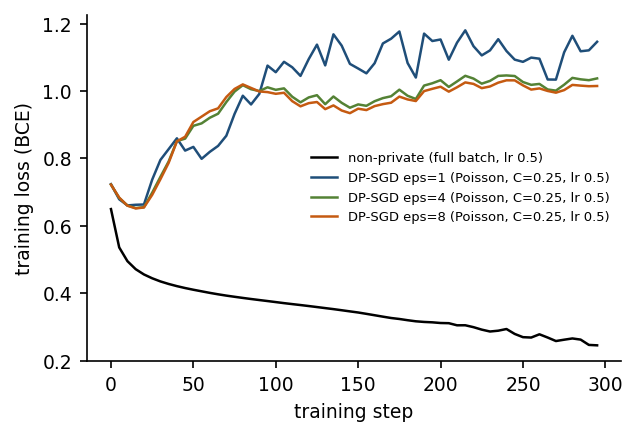

In [12]:
print('Credit_History handling (loan data, non-private, 5x5 CV)'); display(A.credit_history_table())
for d in ('loan', 'german'): print('--- wider MLP search,', d); display(A.mlptune_table(d))
fig('fig_loss.png', 420)

## 7. Learning curve (Taiwan, fixed 6,000-row test set)

,n,reps,logreg_nonprivate,mlp_nonprivate,dp_mlp_eps1,dp_lr_eps1,dp_ebm_eps1,dp_mlp_eps4,dp_lr_eps4,dp_ebm_eps4
0,500,5,0.720 ± 0.006,0.645 ± 0.018,0.638 ± 0.027,0.715 ± 0.011,0.594 ± 0.050,0.697 ± 0.021,0.726 ± 0.005,0.689 ± 0.017
1,1000,5,0.732 ± 0.004,0.664 ± 0.019,0.666 ± 0.033,0.724 ± 0.010,0.659 ± 0.038,0.697 ± 0.039,0.726 ± 0.005,0.734 ± 0.012
2,2000,5,0.738 ± 0.001,0.691 ± 0.010,0.704 ± 0.025,0.728 ± 0.004,0.704 ± 0.018,0.718 ± 0.018,0.728 ± 0.004,0.750 ± 0.006
3,5000,5,0.742 ± 0.004,0.740 ± 0.012,0.721 ± 0.011,0.728 ± 0.005,0.745 ± 0.003,0.724 ± 0.012,0.729 ± 0.005,0.758 ± 0.003
4,10000,5,0.742 ± 0.001,0.756 ± 0.008,0.726 ± 0.006,0.728 ± 0.002,0.756 ± 0.004,0.736 ± 0.005,0.728 ± 0.002,0.763 ± 0.002
5,24000,3,0.744 ± 0.000,0.766 ± 0.004,0.729 ± 0.005,0.728 ± 0.003,0.760 ± 0.001,0.731 ± 0.005,0.728 ± 0.002,0.766 ± 0.000


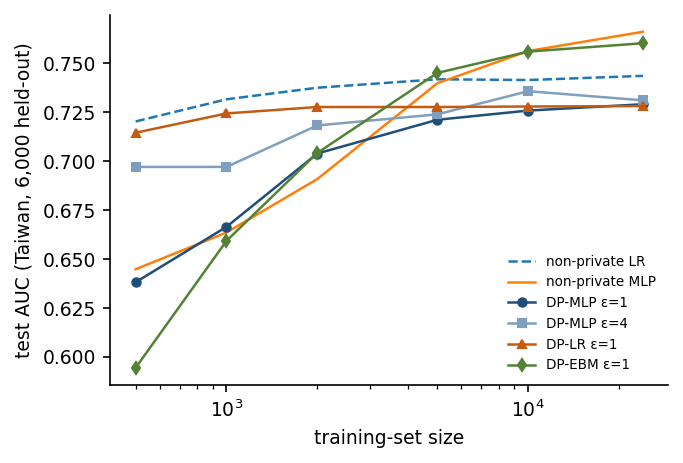

In [13]:
display(A.lc_table()); fig('fig_learning_curve.png', 460)

## 8. Explanation stability

Spearman rank correlation between a DP model's global importance ranking and a non-private reference. The *noise floor* column compares the reference with two non-private networks that differ only in the random seed.

--- Loan approval (n=614)


,"Non-private, re-seeded (noise floor)",DP-SGD ε=0.5,DP-SGD ε=1,DP-SGD ε=2,DP-SGD ε=4,DP-SGD ε=8
IG rank corr. (features),0.76 ± 0.11,0.56 ± 0.10,0.56 ± 0.08,0.53 ± 0.11,0.50 ± 0.13,0.46 ± 0.16
IG rank corr. (units),0.83 ± 0.08,0.65 ± 0.12,0.74 ± 0.13,0.78 ± 0.08,0.80 ± 0.10,0.79 ± 0.14
IG top-3 overlap (units),0.90 ± 0.19,0.80 ± 0.14,0.80 ± 0.15,0.84 ± 0.19,0.87 ± 0.21,0.88 ± 0.20
IG local cosine,0.39 ± 0.05,0.15 ± 0.09,0.20 ± 0.05,0.22 ± 0.03,0.24 ± 0.04,0.25 ± 0.06
PI rank corr. (features),0.37 ± 0.23,0.31 ± 0.20,0.27 ± 0.13,0.27 ± 0.15,0.26 ± 0.13,0.34 ± 0.18
PI rank corr. (units),0.57 ± 0.30,0.46 ± 0.23,0.49 ± 0.17,0.44 ± 0.17,0.49 ± 0.15,0.55 ± 0.21
PI top-3 overlap (units),0.65 ± 0.20,0.63 ± 0.21,0.62 ± 0.19,0.69 ± 0.15,0.66 ± 0.19,0.73 ± 0.17


--- German Credit (n=1000)


,"Non-private, re-seeded (noise floor)",DP-SGD ε=0.5,DP-SGD ε=1,DP-SGD ε=2,DP-SGD ε=4,DP-SGD ε=8
IG rank corr. (features),0.80 ± 0.03,0.74 ± 0.05,0.74 ± 0.04,0.75 ± 0.04,0.75 ± 0.05,0.75 ± 0.06
IG rank corr. (units),0.81 ± 0.03,0.72 ± 0.05,0.72 ± 0.05,0.74 ± 0.06,0.76 ± 0.07,0.77 ± 0.06
IG top-3 overlap (units),0.67 ± 0.11,0.57 ± 0.11,0.60 ± 0.14,0.59 ± 0.14,0.64 ± 0.14,0.66 ± 0.11
IG local cosine,0.14 ± 0.08,0.09 ± 0.05,0.13 ± 0.07,0.17 ± 0.07,0.20 ± 0.07,0.22 ± 0.08
PI rank corr. (features),0.32 ± 0.27,0.30 ± 0.17,0.39 ± 0.21,0.43 ± 0.15,0.46 ± 0.16,0.48 ± 0.13
PI rank corr. (units),0.22 ± 0.26,0.27 ± 0.22,0.33 ± 0.24,0.39 ± 0.14,0.44 ± 0.16,0.48 ± 0.15
PI top-3 overlap (units),0.53 ± 0.14,0.42 ± 0.22,0.52 ± 0.26,0.54 ± 0.16,0.62 ± 0.25,0.67 ± 0.23


--- Taiwan card default (n=30000)


,"Non-private, re-seeded (noise floor)",DP-SGD ε=0.5,DP-SGD ε=1,DP-SGD ε=2,DP-SGD ε=4,DP-SGD ε=8
IG rank corr. (features),0.58 ± 0.43,0.26 ± 0.27,0.38 ± 0.23,0.40 ± 0.21,0.41 ± 0.23,0.43 ± 0.23
IG rank corr. (units),0.92 ± 0.06,0.79 ± 0.13,0.79 ± 0.09,0.83 ± 0.10,0.82 ± 0.07,0.82 ± 0.10
IG top-3 overlap (units),0.97 ± 0.14,0.87 ± 0.09,0.87 ± 0.09,0.91 ± 0.17,0.93 ± 0.19,0.93 ± 0.19
IG local cosine,0.48 ± 0.12,0.25 ± 0.11,0.31 ± 0.06,0.33 ± 0.06,0.34 ± 0.06,0.35 ± 0.05
PI rank corr. (features),0.44 ± 0.33,0.29 ± 0.26,0.31 ± 0.26,0.29 ± 0.16,0.26 ± 0.11,0.26 ± 0.13
PI rank corr. (units),0.75 ± 0.19,0.65 ± 0.17,0.70 ± 0.19,0.69 ± 0.15,0.70 ± 0.17,0.70 ± 0.16
PI top-3 overlap (units),0.90 ± 0.28,0.82 ± 0.31,0.89 ± 0.25,0.89 ± 0.25,0.89 ± 0.25,0.89 ± 0.25


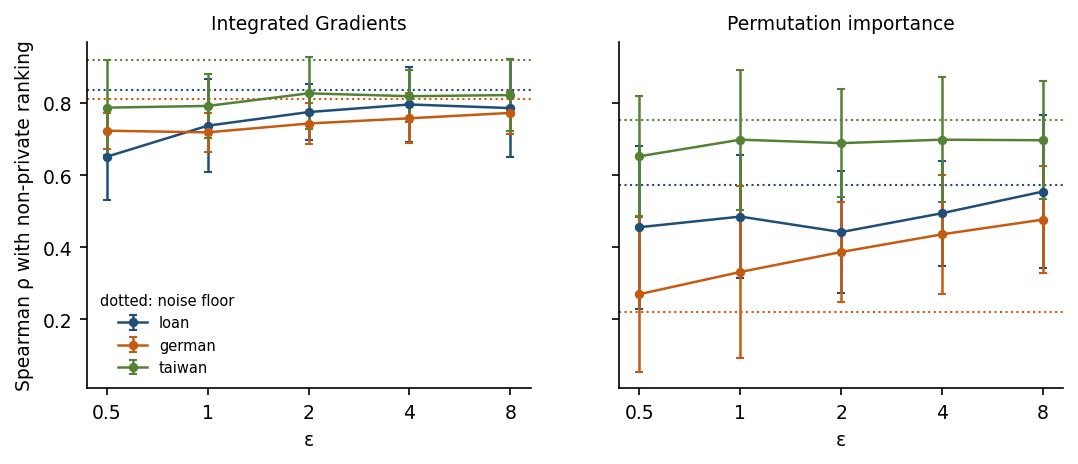

In [14]:
for d in A.DS: print('---', A.NAMES[d]); display(A.expl_summary(d))
fig('fig_expl_stability.png', 700)

--- loan
  IG completeness residual (median, max over rows) : (0.0005145673535169731, 0.033899339160967545)
  IG baseline zero: top-3 overlap with reference, DP eps=1: 0.7999999999999999
  IG baseline median: top-3 overlap with reference, DP eps=1: 0.9222222222222222
  IG baseline modal: top-3 overlap with reference, DP eps=1: 0.9222222222222222
  faithfulness ratio (explanation order / random order), non-private: 3.167860715343192
  faithfulness ratio, DP eps=1: 3.019075078729429
  IG vs PI agreement (units, Spearman), non-private: 0.48166666666666674
--- german
  IG completeness residual (median, max over rows) : (0.0006600761550081338, 0.025823887864261263)
  IG baseline zero: top-3 overlap with reference, DP eps=1: 0.5999999999999999
  IG baseline median: top-3 overlap with reference, DP eps=1: 0.6333333333333333
  IG baseline modal: top-3 overlap with reference, DP eps=1: 0.6333333333333333
  faithfulness ratio (explanation order / random order), non-private: 2.439203757164962
  f

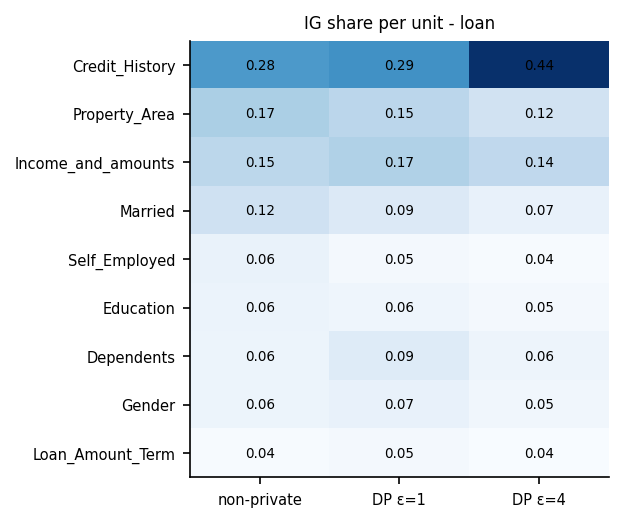

In [15]:
for d in A.DS:
    print('---', d)
    for k, v in A.expl_extra(d).items(): print(f'  {k}: {v}')
fig('fig_expl_heat_loan.png', 360)

## 9. Membership-inference audit

LiRA (fixed variance) over 96 shadow models per setting. `overfit_control` is a deliberately over-trained network and shows that the attack works when there is something to find.

--- Loan approval (n=614)


,Model,ε claimed,Loss-threshold AUC,LiRA AUC (95% CI),LiRA TPR@1%FPR,audit ε lower bound (LiRA)
0,nonprivate,-,0.541,"0.580 [0.572, 0.587]",0.019,0.97
1,overfit_control,-,0.621,"0.709 [0.694, 0.724]",0.062,2.32
2,dp_eps1,1,0.512,"0.508 [0.500, 0.516]",0.010,0.02
3,dp_eps4,4,0.521,"0.529 [0.522, 0.537]",0.014,0.19
4,dp_eps8,8,0.529,"0.546 [0.540, 0.553]",0.016,0.27


--- German Credit (n=1000)


,Model,ε claimed,Loss-threshold AUC,LiRA AUC (95% CI),LiRA TPR@1%FPR,audit ε lower bound (LiRA)
0,nonprivate,-,0.554,"0.589 [0.583, 0.595]",0.018,0.47
1,overfit_control,-,0.672,"0.798 [0.785, 0.810]",0.119,3.52
2,dp_eps1,1,0.515,"0.513 [0.509, 0.520]",0.011,0.03
3,dp_eps4,4,0.545,"0.569 [0.565, 0.575]",0.017,0.44
4,dp_eps8,8,0.558,"0.609 [0.604, 0.615]",0.022,0.87


--- Taiwan card default (n=30000)


,Model,ε claimed,Loss-threshold AUC,LiRA AUC (95% CI),LiRA TPR@1%FPR,audit ε lower bound (LiRA)
0,nonprivate,-,0.627,"0.685 [0.673, 0.697]",0.043,1.43
1,overfit_control,-,0.633,"0.716 [0.703, 0.727]",0.068,2.26
2,dp_eps1,1,0.504,"0.501 [0.495, 0.507]",0.011,0.00
3,dp_eps4,4,0.509,"0.510 [0.504, 0.515]",0.011,0.02
4,dp_eps8,8,0.526,"0.540 [0.534, 0.545]",0.014,0.27


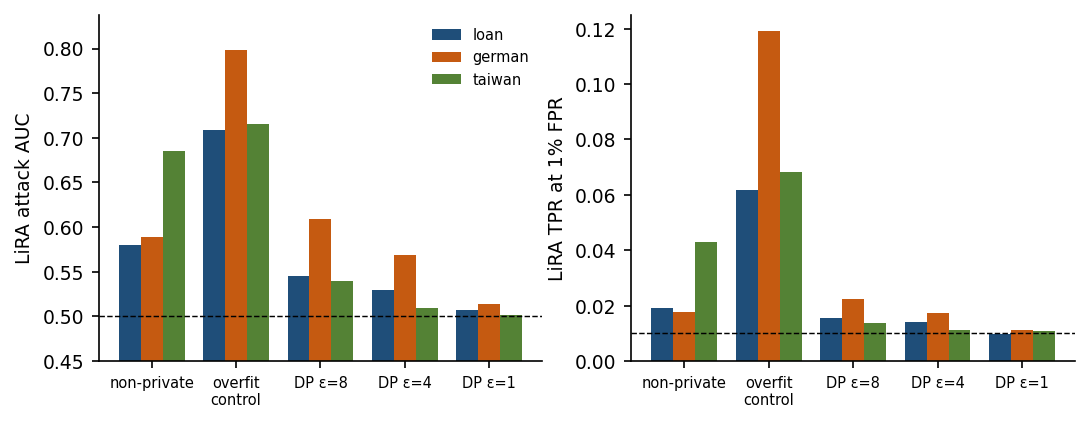

In [16]:
for d in A.DS: print('---', A.NAMES[d]); display(A.mia_table(d))
fig('fig_mia.png', 700)

## 10. Group-level diagnostics

Pooled counts over splits; intervals are bootstrap percentiles over splits. Groups with fewer than 30 pooled rows are dropped.

In [17]:
for d in A.DS:
    t = A.fair_gaps(d); print('---', A.NAMES[d]); display(t[t.Model.str.contains('nonprivate|dp_eps1$|dp_eps4$')])

--- Loan approval (n=614)


,Model,Attribute,Flagged overall,Selection-rate gap,TPR gap,FPR gap
0,with_protected|nonprivate,Gender,0.178,"0.011 [0.002, 0.231]","0.009 [0.004, 0.314]","0.002 [0.001, 0.244]"
1,with_protected|nonprivate,Married,0.178,"0.024 [0.001, 0.052]","0.096 [0.040, 0.152]","0.029 [0.001, 0.065]"
2,with_protected|nonprivate,Property_Area,0.178,"0.088 [0.038, 0.145]","0.054 [0.020, 0.195]","0.063 [0.029, 0.118]"
3,with_protected|dp_eps1,Gender,0.135,"0.006 [0.001, 0.141]","0.005 [0.002, 0.428]","0.004 [0.000, 0.043]"
4,with_protected|dp_eps1,Married,0.135,"0.035 [0.003, 0.074]","0.061 [0.029, 0.089]","0.041 [0.003, 0.092]"
5,with_protected|dp_eps1,Property_Area,0.135,"0.041 [0.014, 0.111]","0.105 [0.024, 0.238]","0.024 [0.007, 0.096]"
6,with_protected|dp_eps4,Gender,0.145,"0.022 [0.003, 0.135]","0.046 [0.002, 0.387]","0.004 [0.000, 0.024]"
7,with_protected|dp_eps4,Married,0.145,"0.010 [0.001, 0.044]","0.100 [0.050, 0.157]","0.008 [0.000, 0.033]"
8,with_protected|dp_eps4,Property_Area,0.145,"0.027 [0.006, 0.076]","0.121 [0.053, 0.235]","0.008 [0.003, 0.031]"
9,without_protected|nonprivate,Gender,0.144,"0.016 [0.001, 0.099]","0.032 [0.001, 0.229]","0.002 [0.000, 0.070]"


--- German Credit (n=1000)


,Model,Attribute,Flagged overall,Selection-rate gap,TPR gap,FPR gap
0,with_protected|nonprivate,Age,0.141,"0.075 [0.040, 0.115]","0.023 [0.001, 0.105]","0.065 [0.020, 0.123]"
1,with_protected|nonprivate,Foreign,0.141,"0.118 [0.070, 0.169]","0.289 [0.214, 0.355]","0.051 [0.012, 0.093]"
2,with_protected|nonprivate,Sex/marital,0.141,"0.060 [0.022, 0.095]","0.049 [0.002, 0.156]","0.042 [0.009, 0.079]"
3,with_protected|dp_eps1,Age,0.047,"0.008 [0.001, 0.030]","0.031 [0.003, 0.093]","0.019 [0.001, 0.064]"
4,with_protected|dp_eps1,Foreign,0.047,"0.021 [0.008, 0.038]","0.035 [0.004, 0.182]","0.014 [0.001, 0.047]"
5,with_protected|dp_eps1,Sex/marital,0.047,"0.018 [0.002, 0.036]","0.004 [0.001, 0.054]","0.023 [0.005, 0.049]"
6,with_protected|dp_eps4,Age,0.158,"0.075 [0.027, 0.148]","0.006 [0.002, 0.084]","0.074 [0.030, 0.139]"
7,with_protected|dp_eps4,Foreign,0.158,"0.122 [0.040, 0.202]","0.311 [0.184, 0.437]","0.051 [0.003, 0.125]"
8,with_protected|dp_eps4,Sex/marital,0.158,"0.063 [0.013, 0.116]","0.051 [0.003, 0.146]","0.046 [0.005, 0.089]"
9,without_protected|nonprivate,Age,0.189,"0.082 [0.019, 0.142]","0.003 [0.002, 0.104]","0.076 [0.015, 0.138]"


--- Taiwan card default (n=30000)


,Model,Attribute,Flagged overall,Selection-rate gap,TPR gap,FPR gap
0,with_protected|nonprivate,Age,0.125,"0.018 [0.007, 0.025]","0.037 [0.029, 0.047]","0.008 [0.001, 0.015]"
1,with_protected|nonprivate,Marriage,0.125,"0.040 [0.017, 0.074]","0.136 [0.039, 0.238]","0.012 [0.005, 0.030]"
2,with_protected|nonprivate,Sex,0.125,"0.030 [0.019, 0.039]","0.031 [0.001, 0.063]","0.015 [0.010, 0.020]"
3,with_protected|dp_eps1,Age,0.114,"0.016 [0.009, 0.024]","0.032 [0.012, 0.048]","0.008 [0.001, 0.015]"
4,with_protected|dp_eps1,Marriage,0.114,"0.016 [0.010, 0.059]","0.083 [0.025, 0.166]","0.028 [0.007, 0.057]"
5,with_protected|dp_eps1,Sex,0.114,"0.022 [0.014, 0.029]","0.012 [0.000, 0.031]","0.012 [0.006, 0.017]"
6,with_protected|dp_eps4,Age,0.115,"0.017 [0.009, 0.024]","0.035 [0.021, 0.049]","0.008 [0.001, 0.015]"
7,with_protected|dp_eps4,Marriage,0.115,"0.014 [0.011, 0.053]","0.093 [0.025, 0.149]","0.027 [0.005, 0.056]"
8,with_protected|dp_eps4,Sex,0.115,"0.023 [0.015, 0.031]","0.011 [0.001, 0.030]","0.013 [0.006, 0.019]"
9,without_protected|nonprivate,Age,0.120,"0.028 [0.021, 0.035]","0.062 [0.046, 0.074]","0.014 [0.007, 0.020]"


## 11. Re-running one split from scratch

The first loan split is re-run from the raw CSV with the code in `run_cv.py` and compared with the saved result. Differences below 1e-6 count as identical.

In [18]:
import time, run_cv
from sklearn.model_selection import RepeatedStratifiedKFold
ds = load('loan'); tr, te = next(iter(RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=0).split(ds.df, ds.split_y)))
t0 = time.time(); fresh = run_cv.one_split(ds, run_cv.CFG['loan'], 0, tr, te); saved = json.load(open(os.path.join(V2, 'results', 'cv_loan.json')))[0]
worst, nm = 0.0, 0
for m, d in saved['models'].items():
    for k, v in d.items():
        if isinstance(v, float) and m in fresh['models'] and k in fresh['models'][m]: worst = max(worst, abs(v - fresh['models'][m][k])); nm += 1
print(f'{nm} metric values compared in {time.time()-t0:.0f}s; largest absolute difference = {worst:.2e}')
assert worst < 1e-6

202 metric values compared in 19s; largest absolute difference = 0.00e+00


## What this notebook shows

Each statement in the paper's Results section corresponds to a table or figure produced above from files whose hashes are checked in section 1, and the code that produced those files reproduces a split exactly (section 11). To recreate everything from the raw data run `v2/run_all.sh`.